# Machine Learning – Unidad 3

## PCA y benchmarking de algoritmos de clustering

**Dataset:** House Prices – Advanced Regression Techniques  
**Continuidad:** Unidad 1 y Unidad 2  
**Integrantes:**  
- Muñoz Morales, Diego Ignacio
- Villarroel Montecinos, Yenny Vanessa
- Matujara Contreras, Jordan Hernán
- Sepúlveda Alvial, Segundo Alejandro

**Profesor:** Jorge Luis Padilla  

---

## Propósito del cuaderno

Este cuaderno desarrolla el Trabajo N°3 de Machine Learning, aplicando lo aprendido en la Unidad 3 sobre preparación de datos, reducción de dimensionalidad con PCA, algoritmos de clustering y evaluación de modelos no supervisados.

El trabajo mantiene continuidad con las unidades anteriores:

- En la Unidad 1 se preparó un pipeline reproducible con el dataset House Prices.
- En la Unidad 2 se reformuló el problema como clasificación binaria mediante la variable `HighPrice`.
- En la Unidad 3 se utiliza esa variable conocida solo como referencia externa para analizar si los algoritmos de clustering logran diferenciar viviendas de alto y bajo precio.

Es importante aclarar que los algoritmos de clustering no utilizan `HighPrice` para entrenar. Esta variable solo se usa al final para evaluar si los grupos encontrados tienen relación con la separación conocida entre viviendas de alto y bajo precio.

## Punto 1. Preparación de datos

En esta etapa se realiza la preparación de los datos, considerando lo trabajado en la Unidad 1.

Las principales decisiones aplicadas son:

- Limpieza de datos.
- Eliminación de variables no predictivas.
- Tratamiento de valores faltantes.
- Aplicación de One Hot Encoding para variables categóricas.
- Normalización de los datos.

La normalización es especialmente importante porque varios algoritmos de clustering trabajan con distancias. Si las variables están en escalas distintas, aquellas con valores más grandes pueden dominar artificialmente el cálculo de distancia.

In [1]:
# ==========================
# Librerías principales
# ==========================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

### Carga del dataset

Se utiliza el archivo `train.csv` del dataset House Prices. Este archivo fue trabajado previamente en las unidades anteriores, por lo que permite mantener continuidad metodológica.

Antes de ejecutar esta celda, el archivo `train.csv` debe estar cargado en Colab.

In [2]:
# ==========================
# Carga del dataset
# ==========================

df = pd.read_csv("train.csv")

print("Dimensiones originales del dataset:", df.shape)
df.head()

Dimensiones originales del dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.0000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.0000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.0000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.0000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.0000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Limpieza inicial y construcción de variable de referencia

Se elimina la columna `Id`, ya que corresponde únicamente a un identificador de registros y no representa una característica de la vivienda.

Además, se crea la variable `HighPrice`, utilizada en la Unidad 2. Esta variable toma el valor 1 si el precio de venta de la vivienda está sobre la mediana, y 0 si está bajo o igual a la mediana.

En este trabajo, `HighPrice` no se utilizará para entrenar los modelos de clustering. Solo se usará posteriormente como referencia externa para evaluar si los clusters diferencian correctamente viviendas de alto y bajo precio.

In [3]:
# ==========================
# Limpieza inicial
# ==========================

if "Id" in df.columns:
    df = df.drop("Id", axis=1)

# Variable de referencia externa
df["HighPrice"] = (df["SalePrice"] > df["SalePrice"].median()).astype(int)

print("Mediana de SalePrice:", df["SalePrice"].median())
print("\nDistribución de HighPrice:")
print(df["HighPrice"].value_counts(normalize=True))

Mediana de SalePrice: 163000.0

Distribución de HighPrice:
HighPrice
0   0.5014
1   0.4986
Name: proportion, dtype: float64


### Tratamiento de valores faltantes

Los valores faltantes se tratan según el tipo de variable:

- En variables numéricas se utiliza la mediana, ya que es una medida robusta frente a valores extremos.
- En variables categóricas se utiliza la categoría `"None"`, lo que permite conservar la información de ausencia sin eliminar registros.

Esta etapa es necesaria porque los algoritmos de machine learning no trabajan correctamente con valores faltantes.

In [4]:
# ==========================
# Tratamiento de missing values
# ==========================

for col in df.select_dtypes(include=["int64", "float64"]).columns:
    if col not in ["SalePrice", "HighPrice"]:
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna("None")

print("Total de valores faltantes después de la imputación:", df.isnull().sum().sum())

Total de valores faltantes después de la imputación: 0


### One Hot Encoding y normalización

El dataset contiene variables categóricas, por lo que se aplica One Hot Encoding para convertirlas a formato numérico.

Luego se aplica normalización mediante `StandardScaler`, ya que los algoritmos de clustering basados en distancia son sensibles a la escala de las variables.

También se excluyen `SalePrice` y `HighPrice` de las variables de entrada. Esto evita que el algoritmo agrupe directamente por el precio o por la etiqueta binaria conocida.

In [5]:
# ==========================
# Definición de variables
# ==========================

X = df.drop(["SalePrice", "HighPrice"], axis=1)
y_reference = df["HighPrice"]

# One Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Dimensiones después del One Hot Encoding:", X_encoded.shape)
print("Dimensiones después de la normalización:", X_scaled.shape)

Dimensiones después del One Hot Encoding: (1460, 260)
Dimensiones después de la normalización: (1460, 260)


### Comentario del Punto 1

La preparación de datos permite dejar el dataset en condiciones adecuadas para aplicar algoritmos de clustering.

Se aplicó One Hot Encoding porque existían variables categóricas, y normalización porque los métodos basados en distancia pueden verse afectados si las variables tienen escalas distintas.

Además, se excluyó la variable `SalePrice` para evitar que el clustering se construya directamente en función del precio real. La variable `HighPrice` se mantiene únicamente como referencia para evaluar posteriormente la calidad de los clusters.

## Punto 2. Experimento con y sin PCA

En este punto se comparan dos escenarios:

1. Base de datos sin PCA.
2. Base de datos con PCA.

PCA permite reducir la dimensionalidad del dataset conservando la mayor cantidad posible de información. Esto es útil porque después del One Hot Encoding el número de variables aumenta considerablemente.

Se utilizará como criterio conservar al menos el 90% de la varianza explicada. De esta forma, se busca reducir la complejidad del dataset sin perder demasiada información.

In [6]:
# ==========================
# PCA completo para analizar varianza explicada
# ==========================

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_variance_cum = np.cumsum(pca_full.explained_variance_ratio_)

n_components_90 = np.argmax(explained_variance_cum >= 0.90) + 1

print("Número mínimo de componentes para explicar al menos 90% de la varianza:", n_components_90)
print("Varianza acumulada alcanzada:", explained_variance_cum[n_components_90 - 1])

Número mínimo de componentes para explicar al menos 90% de la varianza: 139
Varianza acumulada alcanzada: 0.9000121423695805


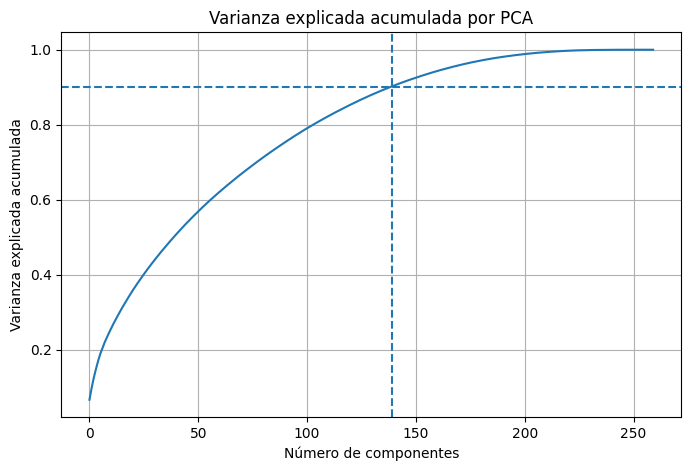

In [7]:
# ==========================
# Gráfico de varianza explicada acumulada
# ==========================

plt.figure(figsize=(8, 5))
plt.plot(explained_variance_cum)
plt.axhline(y=0.90, linestyle="--")
plt.axvline(x=n_components_90, linestyle="--")
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

### Aplicación de PCA

A partir del análisis de varianza explicada, se selecciona el número mínimo de componentes necesario para conservar al menos el 90% de la información.

Además, se genera una versión PCA de dos componentes solo para visualización gráfica. Esta visualización no reemplaza las métricas, pero ayuda a interpretar la separación de los grupos.

In [8]:
# ==========================
# Base con PCA
# ==========================

pca = PCA(n_components=n_components_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# PCA 2D solo para visualización
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Base sin PCA:", X_scaled.shape)
print("Base con PCA 90%:", X_pca.shape)
print("Base PCA 2D para visualización:", X_pca_2d.shape)

Base sin PCA: (1460, 260)
Base con PCA 90%: (1460, 139)
Base PCA 2D para visualización: (1460, 2)


### Comentario del Punto 2

El experimento con y sin PCA permite comparar si la reducción de dimensionalidad mejora la calidad de los clusters.

La base sin PCA conserva todas las variables generadas después del One Hot Encoding, mientras que la base con PCA reduce la dimensionalidad manteniendo al menos el 90% de la varianza.

Esta comparación es importante porque algunos algoritmos basados en distancia pueden verse afectados por espacios de alta dimensión.

## Punto 3. Challenge entre algoritmos de distancia y densidad

Se realiza un benchmarking con cinco algoritmos de clustering, cumpliendo con lo solicitado en la pauta.

Los modelos utilizados son:

1. **K-Means:** algoritmo basado en distancia.
2. **Agglomerative Clustering:** algoritmo jerárquico basado en distancia.
3. **Gaussian Mixture:** modelo probabilístico asociado a densidad.
4. **DBSCAN:** algoritmo basado en densidad.
5. **OPTICS:** algoritmo basado en densidad.

Cada modelo será evaluado en dos escenarios:

- Sin PCA.
- Con PCA.

In [9]:
# ==========================
# Función de evaluación de clustering
# ==========================

def evaluate_clustering(X_data, labels, y_true, model_name, dataset_type):
    labels = np.array(labels)
    unique_labels = set(labels)

    # En DBSCAN y OPTICS, la etiqueta -1 representa ruido
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = int(np.sum(labels == -1))

    # Si hay menos de 2 clusters, no se pueden calcular métricas internas
    if n_clusters < 2:
        return {
            "Modelo": model_name,
            "Base": dataset_type,
            "Clusters": n_clusters,
            "Ruido": n_noise,
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan,
            "ARI": np.nan,
            "NMI": np.nan
        }

    return {
        "Modelo": model_name,
        "Base": dataset_type,
        "Clusters": n_clusters,
        "Ruido": n_noise,
        "Silhouette": silhouette_score(X_data, labels),
        "Davies_Bouldin": davies_bouldin_score(X_data, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_data, labels),
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels)
    }

In [10]:
# ==========================
# Función para ejecutar benchmarking
# ==========================

def run_benchmark(X_data, y_true, dataset_type):
    results = []

    models = {
        "KMeans": KMeans(n_clusters=2, random_state=42, n_init=20),
        "Agglomerative": AgglomerativeClustering(n_clusters=2),
        "GaussianMixture": GaussianMixture(n_components=2, random_state=42),
        "DBSCAN": DBSCAN(eps=5, min_samples=5),
        "OPTICS": OPTICS(min_samples=10, xi=0.05)
    }

    for name, model in models.items():
        labels = model.fit_predict(X_data)
        result = evaluate_clustering(X_data, labels, y_true, name, dataset_type)
        results.append(result)

    return pd.DataFrame(results)

In [11]:
# ==========================
# Ejecución del benchmark
# ==========================

results_no_pca = run_benchmark(X_scaled, y_reference, "Sin PCA")
results_pca = run_benchmark(X_pca, y_reference, "Con PCA")

results = pd.concat([results_no_pca, results_pca], ignore_index=True)

results

,Modelo,Base,Clusters,Ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI,NMI
0,KMeans,Sin PCA,2,0,0.0531,3.7317,79.8044,0.4763,0.4014
1,Agglomerative,Sin PCA,2,0,0.0304,3.8762,67.2010,0.3449,0.3037
2,GaussianMixture,Sin PCA,2,0,0.0815,4.5361,60.4550,0.3290,0.2633
3,DBSCAN,Sin PCA,6,1409,-0.2428,2.2615,2.1614,0.0016,0.0505
4,OPTICS,Sin PCA,2,1435,-0.1424,1.7944,7.2279,0.0002,0.0300
5,KMeans,Con PCA,2,0,0.0611,3.4883,89.3128,0.4707,0.3972
6,Agglomerative,Con PCA,2,0,0.0259,3.5072,74.0099,0.2953,0.2788
7,GaussianMixture,Con PCA,2,0,0.0732,4.1325,70.2157,0.3337,0.2573
8,DBSCAN,Con PCA,8,1352,-0.2197,2.1002,3.8242,0.0078,0.0831
9,OPTICS,Con PCA,4,1405,-0.2249,2.1441,5.5191,0.0014,0.0582


### Comentario del Punto 3

El benchmarking permite comparar el desempeño de diferentes algoritmos bajo las mismas condiciones.

Los algoritmos basados en distancia, como K-Means y Agglomerative Clustering, buscan formar grupos compactos y separados. Los modelos basados en densidad, como DBSCAN y OPTICS, buscan regiones con alta concentración de datos y pueden identificar ruido.

Gaussian Mixture, por su parte, trabaja desde un enfoque probabilístico, asignando observaciones a componentes con cierta probabilidad.

La comparación con y sin PCA permite evaluar si la reducción de dimensionalidad mejora o perjudica la formación de clusters.

## Punto 4. Evaluación de modelos con métricas

Para evaluar los modelos de clustering se utilizan métricas internas y externas.

### Métricas internas

Estas métricas evalúan la calidad del clustering sin utilizar etiquetas reales:

- **Silhouette Score:** mide qué tan bien separado está cada cluster. Mientras mayor sea, mejor.
- **Davies-Bouldin Index:** mide la relación entre compacidad y separación. Mientras menor sea, mejor.
- **Calinski-Harabasz Index:** mide separación entre clusters respecto a la dispersión interna. Mientras mayor sea, mejor.

### Métricas externas

Dado que desde la Unidad 2 conocemos la variable `HighPrice`, podemos usarla como referencia externa para analizar si los clusters coinciden con la separación entre viviendas de alto y bajo precio.

- **ARI:** mide la similitud entre etiquetas reales y clusters, ajustada por azar.
- **NMI:** mide la información compartida entre los clusters y la variable conocida.

La selección del modelo final se realizará considerando principalmente ARI y NMI, complementando con las métricas internas.

In [12]:
# ==========================
# Ordenamiento de resultados
# ==========================

results_sorted = results.sort_values(
    by=["ARI", "NMI", "Silhouette"],
    ascending=[False, False, False]
).reset_index(drop=True)

results_sorted

,Modelo,Base,Clusters,Ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI,NMI
0,KMeans,Sin PCA,2,0,0.0531,3.7317,79.8044,0.4763,0.4014
1,KMeans,Con PCA,2,0,0.0611,3.4883,89.3128,0.4707,0.3972
2,Agglomerative,Sin PCA,2,0,0.0304,3.8762,67.2010,0.3449,0.3037
3,GaussianMixture,Con PCA,2,0,0.0732,4.1325,70.2157,0.3337,0.2573
4,GaussianMixture,Sin PCA,2,0,0.0815,4.5361,60.4550,0.3290,0.2633
5,Agglomerative,Con PCA,2,0,0.0259,3.5072,74.0099,0.2953,0.2788
6,DBSCAN,Con PCA,8,1352,-0.2197,2.1002,3.8242,0.0078,0.0831
7,DBSCAN,Sin PCA,6,1409,-0.2428,2.2615,2.1614,0.0016,0.0505
8,OPTICS,Con PCA,4,1405,-0.2249,2.1441,5.5191,0.0014,0.0582
9,OPTICS,Sin PCA,2,1435,-0.1424,1.7944,7.2279,0.0002,0.0300


In [13]:
# ==========================
# Selección del mejor modelo
# ==========================

best_row = results_sorted.iloc[0]

print("Modelo seleccionado:", best_row["Modelo"])
print("Base utilizada:", best_row["Base"])
print("ARI:", best_row["ARI"])
print("NMI:", best_row["NMI"])
print("Silhouette:", best_row["Silhouette"])

best_row

Modelo seleccionado: KMeans
Base utilizada: Sin PCA
ARI: 0.47631827808979904
NMI: 0.4014309657071135
Silhouette: 0.05311658666003659


,0
Modelo,KMeans
Base,Sin PCA
Clusters,2
Ruido,0
Silhouette,0.0531
Davies_Bouldin,3.7317
Calinski_Harabasz,79.8044
ARI,0.4763
NMI,0.4014


### Generación de etiquetas del modelo seleccionado

A continuación, se vuelve a entrenar el modelo seleccionado para obtener sus etiquetas de cluster y analizar su relación con la variable `HighPrice`.

In [14]:
# ==========================
# Reentrenamiento del mejor modelo
# ==========================

best_model_name = best_row["Modelo"]
best_base = best_row["Base"]

X_best = X_pca if best_base == "Con PCA" else X_scaled

if best_model_name == "KMeans":
    best_model = KMeans(n_clusters=2, random_state=42, n_init=20)
elif best_model_name == "Agglomerative":
    best_model = AgglomerativeClustering(n_clusters=2)
elif best_model_name == "GaussianMixture":
    best_model = GaussianMixture(n_components=2, random_state=42)
elif best_model_name == "DBSCAN":
    best_model = DBSCAN(eps=5, min_samples=5)
else:
    best_model = OPTICS(min_samples=10, xi=0.05)

best_labels = best_model.fit_predict(X_best)

print("Distribución de clusters:")
print(pd.Series(best_labels).value_counts())

Distribución de clusters:
0    852
1    608
Name: count, dtype: int64


### Análisis contra la variable conocida `HighPrice`

La siguiente tabla permite analizar si los clusters generados por el modelo seleccionado tienen relación con la variable `HighPrice`.

Si un cluster concentra mayor proporción de viviendas con `HighPrice = 1` y otro cluster concentra más viviendas con `HighPrice = 0`, entonces el algoritmo logró diferenciar parcialmente viviendas de alto y bajo precio.

In [15]:
# ==========================
# Tabla cruzada cluster vs HighPrice
# ==========================

cluster_analysis = pd.crosstab(
    pd.Series(best_labels, name="Cluster"),
    pd.Series(y_reference.values, name="HighPrice"),
    normalize="index"
)

cluster_analysis

HighPrice,0,1
Cluster,,
0,0.7969,0.2031
1,0.0872,0.9128


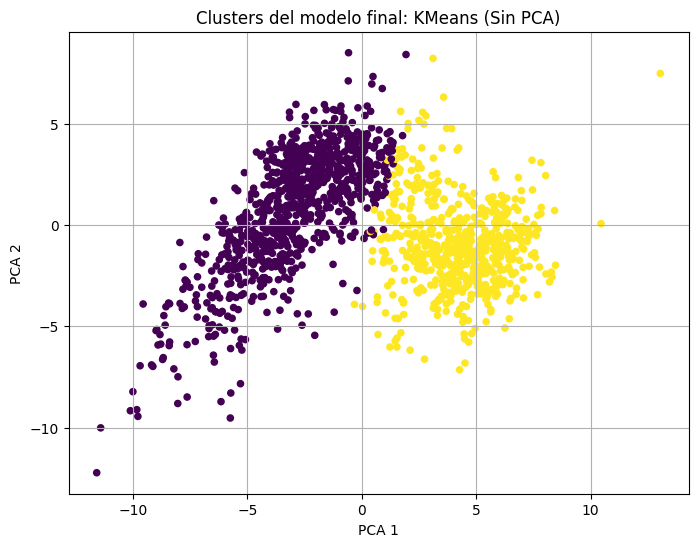

In [16]:
# ==========================
# Visualización 2D de clusters
# ==========================

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=best_labels, s=20)
plt.title(f"Clusters del modelo final: {best_model_name} ({best_base})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

### Comentario del Punto 4

El modelo final se selecciona considerando el equilibrio entre métricas internas y externas.

Las métricas internas permiten evaluar si los clusters son compactos y separados. Sin embargo, como se conoce la variable `HighPrice`, también es posible evaluar si los clusters tienen relación con la separación entre viviendas de alto y bajo precio.

En este contexto, ARI y NMI son especialmente importantes, ya que permiten comparar los clusters con la variable de referencia. Si estos valores son altos, significa que los clusters se asemejan más a la separación conocida.

La tabla cruzada complementa el análisis, ya que permite observar directamente qué proporción de viviendas de alto y bajo precio queda en cada cluster.

## Conclusión

En este trabajo se aplicaron técnicas de preparación de datos, reducción de dimensionalidad mediante PCA y benchmarking de algoritmos de clustering, dando continuidad a los trabajos de las unidades anteriores.

A partir de los resultados obtenidos, el modelo seleccionado fue KMeans sin PCA, ya que presentó el mejor desempeño según las métricas externas ARI y NMI. Esto indica que los clusters generados tienen una relación moderada con la variable HighPrice, utilizada como referencia externa.

Si bien el valor de Silhouette fue bajo, lo que sugiere que los grupos no están completamente separados desde una perspectiva interna, la tabla cruzada muestra que el algoritmo logró diferenciar de manera razonable viviendas de alto y bajo precio.

Finalmente, se concluye que KMeans sin PCA es la mejor alternativa dentro del benchmarking realizado, ya que logra el mejor equilibrio entre interpretación, simplicidad y correspondencia con la variable conocida.

## Punto 5. Carga del cuaderno en GitHub

El cuaderno Python será cargado en GitHub para asegurar trazabilidad, versionado y reproducibilidad del trabajo.

GitHub permite que el desarrollo pueda ser revisado, descargado y ejecutado nuevamente por otros usuarios, manteniendo transparencia en el proceso.

Repositorio GitHub:

https://github.com/diegomunozmo-ops/Trabajo-3-machine-learning.git

## Bibliografía

- Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*.
- Hastie, T., Tibshirani, R., & Friedman, J. *The Elements of Statistical Learning*.
- Kaggle. *House Prices – Advanced Regression Techniques*.
- Material de clases de la Unidad 3.